## Import Required Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Load The Dataset

In [2]:
df = pd.read_csv("insurance.csv")
df.head()

,age,sex,bmi,children,smoker,region,expenses
0,19,female,27.9,0,yes,southwest,16884.92
1,18,male,33.8,1,no,southeast,1725.55
2,28,male,33.0,3,no,southeast,4449.46
3,33,male,22.7,0,no,northwest,21984.47
4,32,male,28.9,0,no,northwest,3866.86


## Encode Categorical Columns

In [30]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df['sex'] = le.fit_transform(df['sex'])
df['smoker'] = le.fit_transform(df['smoker'])
df['region'] = le.fit_transform(df['region'])

## Understand The Dataset

In [5]:
df.shape
df.info()
df.describe()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   expenses  1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


,age,bmi,children,expenses
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.665471,1.094918,13270.422414
std,14.049960,6.098382,1.205493,12110.011240
min,18.000000,16.000000,0.000000,1121.870000
25%,27.000000,26.300000,0.000000,4740.287500
50%,39.000000,30.400000,1.000000,9382.030000
75%,51.000000,34.700000,2.000000,16639.915000
max,64.000000,53.100000,5.000000,63770.430000


## Check The Missing Values

In [6]:
df.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
expenses    0
dtype: int64

In [7]:
df = df.dropna()

## Check Uique Values

In [8]:
df.nunique()

age           47
sex            2
bmi          275
children       6
smoker         2
region         4
expenses    1337
dtype: int64

## DATA VISUVALIZATION

## Age Distribution

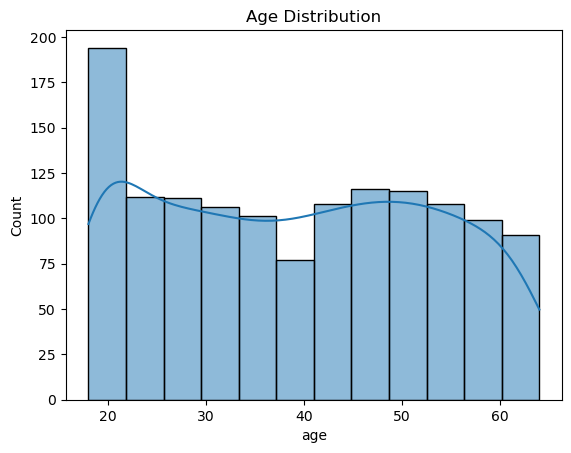

In [9]:
sns.histplot(df['age'], kde=True)
plt.title("Age Distribution")
plt.show()

## Gender Count

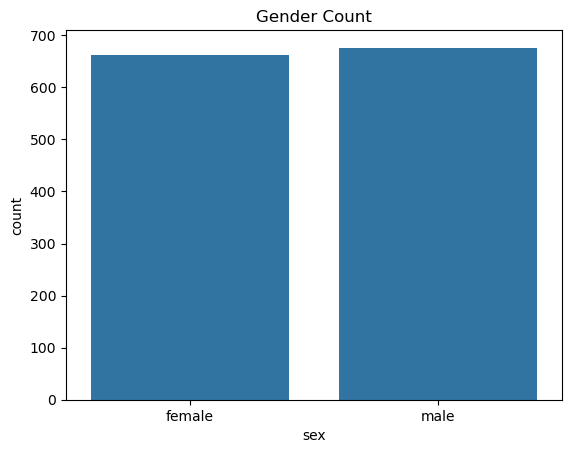

In [10]:
sns.countplot(x='sex', data=df)
plt.title("Gender Count")
plt.show()

In [21]:
print(df.columns)

Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'expenses'], dtype='object')


## Smoker vs charges

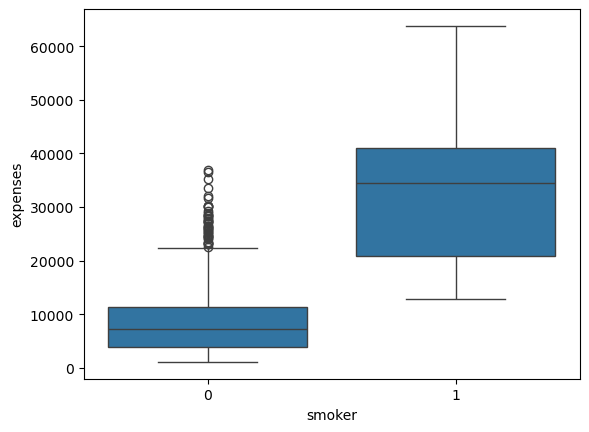

In [22]:
sns.boxplot(x='smoker', y='expenses', data=df)
plt.show()

## Correlation Heatmap

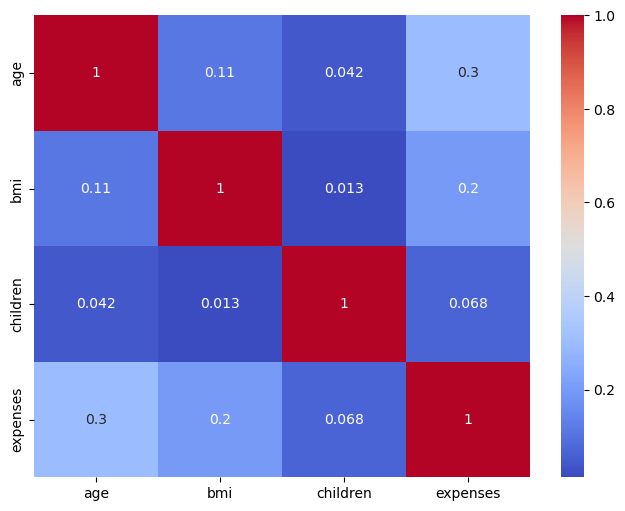

In [12]:
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.show()

## Plot Graph

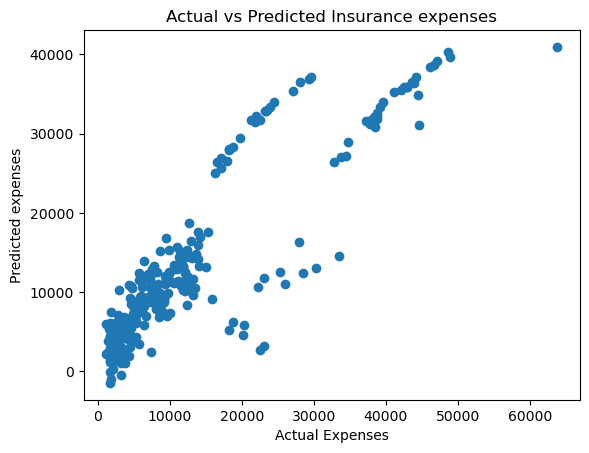

In [31]:
import matplotlib.pyplot as plt

plt.scatter(y_test, y_pred)
plt.xlabel("Actual Expenses")
plt.ylabel("Predicted expenses")
plt.title("Actual vs Predicted Insurance expenses")
plt.show()

## Convert Categorical Data to Numerical

In [13]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df['sex'] = le.fit_transform(df['sex'])
df['smoker'] = le.fit_transform(df['smoker'])
df['region'] = le.fit_transform(df['region'])

## Define Features and Target

In [23]:
X = df.drop('expenses', axis=1)
y = df['expenses']

## Train Test Split

In [25]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

## Train the Model

In [26]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(X_train, y_train)

print("Model trained successfully")

Model trained successfully


## Make Predictions

In [27]:
y_pred = model.predict(X_test)

## Check Model Accuracy

In [28]:
from sklearn.metrics import r2_score

score = r2_score(y_test, y_pred)
print("Model Accuracy:", score)

Model Accuracy: 0.7833214205203848


## Univariate analysis

## Histogram

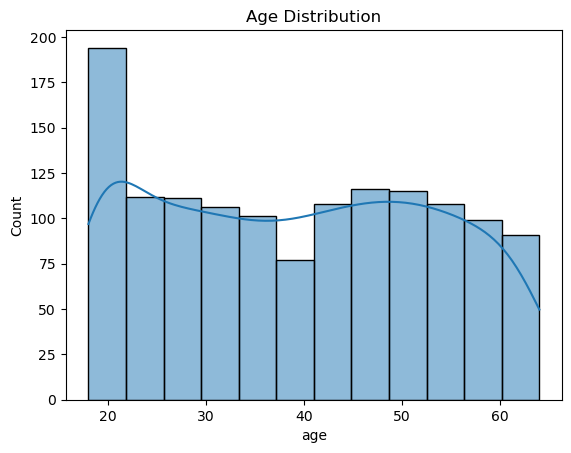

In [45]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(df['age'], kde=True)

plt.title("Age Distribution")

plt.show()

## Boxplot

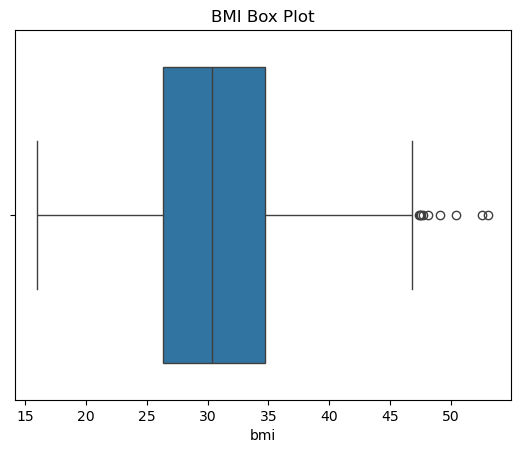

In [46]:
sns.boxplot(x=df['bmi'])

plt.title("BMI Box Plot")

plt.show()

## Barchart

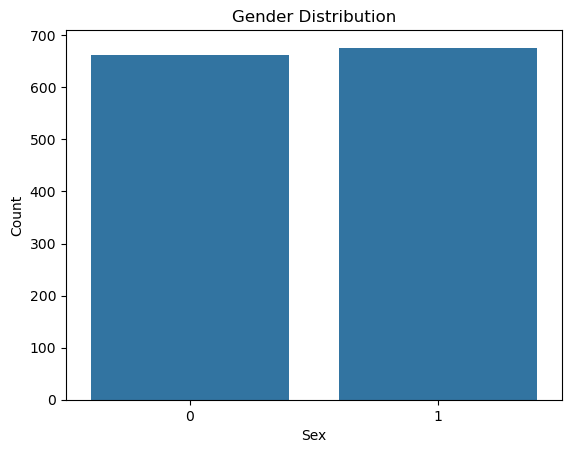

In [47]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.countplot(x='sex', data=df)

plt.title("Gender Distribution")

plt.xlabel("Sex")
plt.ylabel("Count")

plt.show()

## Pi Chart

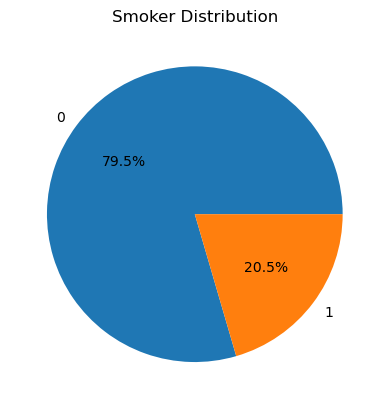

In [48]:
df['smoker'].value_counts().plot.pie(autopct='%1.1f%%')

plt.title("Smoker Distribution")

plt.ylabel("")

plt.show()

## Bivariate Analysis

## Scatterplot(num vs num)

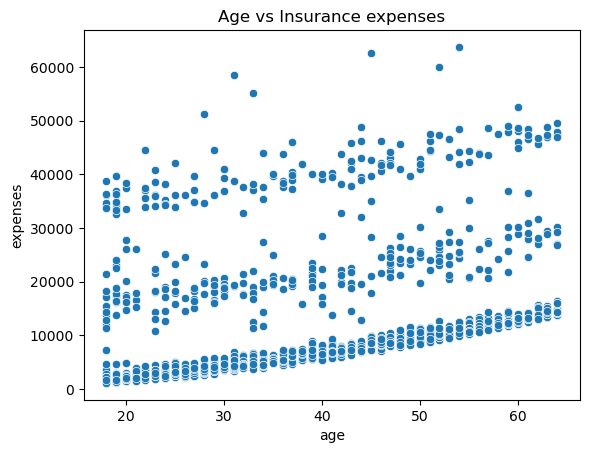

In [38]:
sns.scatterplot(x='age', y='expenses', data=df)
plt.title("Age vs Insurance expenses")
plt.show()

## Barplot(num vs cat)

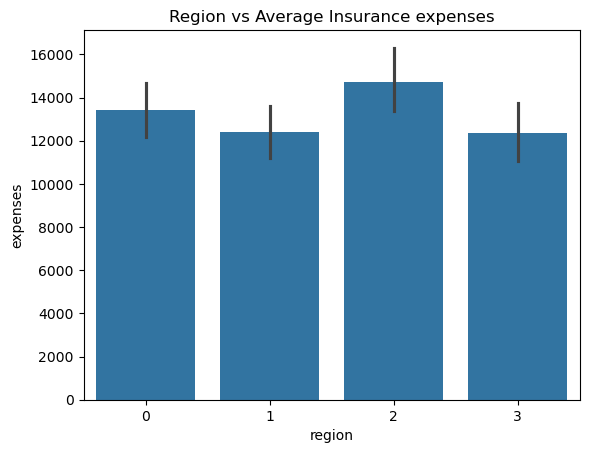

In [40]:
sns.barplot(x='region', y='expenses', data=df)

plt.title("Region vs Average Insurance expenses")

plt.show()

## countplot(cat vs cat)

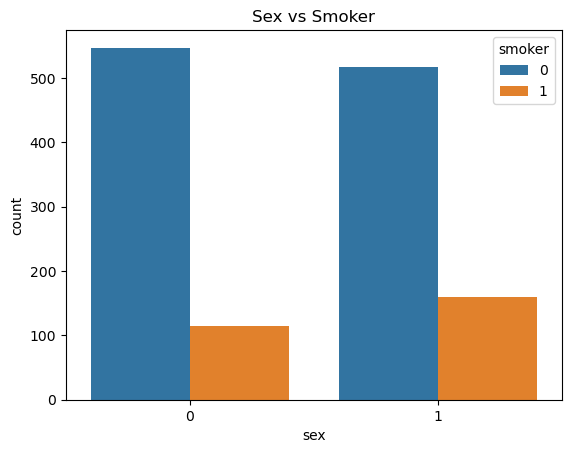

In [54]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='sex', hue='smoker', data=df)

plt.title("Sex vs Smoker")

plt.show()

## LINEPLOT

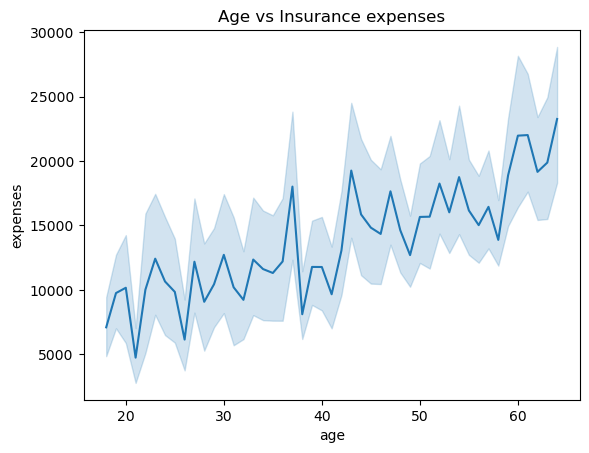

In [42]:
sns.lineplot(x='age', y='expenses', data=df)

plt.title("Age vs Insurance expenses")

plt.show()

## Boxplot(num vs cat)

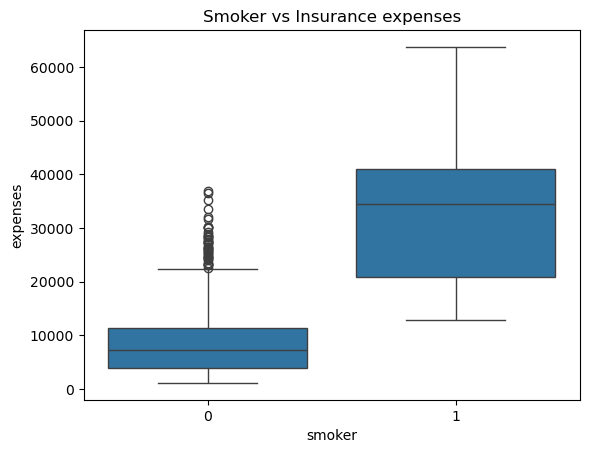

In [51]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(x='smoker', y='expenses', data=df)

plt.title("Smoker vs Insurance expenses")

plt.show()

## Violin Plot(distribution and density of numerical data across categories)

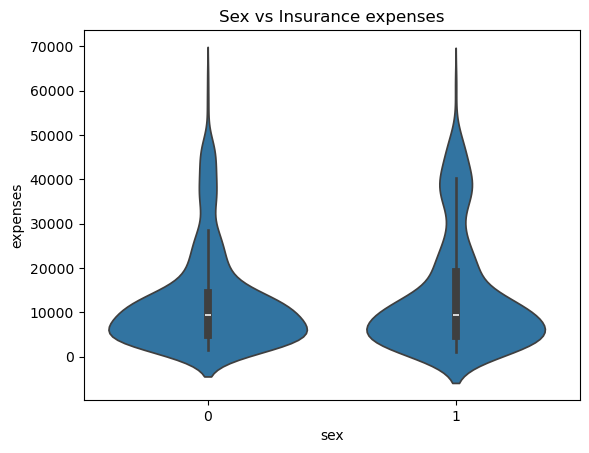

In [53]:
sns.violinplot(x='sex', y='expenses', data=df)

plt.title("Sex vs Insurance expenses")

plt.show()

## Evaluate Model

In [29]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print("MAE:", mean_absolute_error(y_test, y_pred))
print("MSE:", mean_squared_error(y_test, y_pred))
print("R2 Score:", r2_score(y_test, y_pred))

MAE: 4186.940106317013
MSE: 33639075.08997807
R2 Score: 0.7833214205203848


## Actual vs Predicted Graph

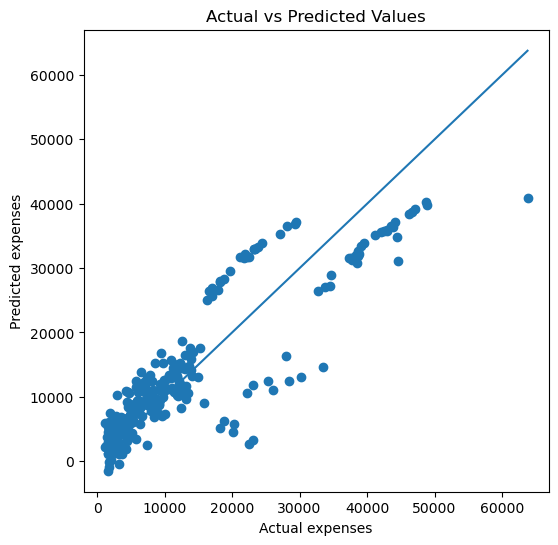

In [32]:
plt.figure(figsize=(6,6))

plt.scatter(y_test, y_pred)

plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()])

plt.xlabel("Actual expenses")
plt.ylabel("Predicted expenses")
plt.title("Actual vs Predicted Values")

plt.show()

## Save The Model

In [20]:
import joblib

joblib.dump(model, "insurance_model.pkl")

['insurance_model.pkl']